In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import torch
from scipy.stats import norm
from scipy.signal import lfilter
from glob import glob
import h5py
from transformer import EncTransformer
import seaborn as sns
from sklearn.decomposition import PCA

In [6]:
# loading data of spikes
def bin_spikes_counts(data, bin_size=20):
    """
    data: (trials, time, neurons)
    bin_size: in timesteps (e.g., 20 if 1 ms bins)
    """
    T = data.shape[1]
    T_trim = (T // bin_size) * bin_size

    data_trim = data[:, :T_trim, :]

    binned = data_trim.reshape(
        data.shape[0],
        T_trim // bin_size,
        bin_size,
        data.shape[2]
    ).sum(axis=2)  # 🔥 key: SUM, not mean

    return binned

def filter_gauss(spike_tensor, SD):
    """
    spike_tensor: (trials, time, neurons)
    SD: standard deviation in ms (same units as time bins)

    returns:
        smoothed firing rate (same shape), in spikes/ms
    """

    # --- Gaussian kernel ---
    SDrounded = int(2 * round(SD / 2))
    gausswidth = int(8 * SDrounded)

    x = np.arange(1, gausswidth + 1)
    F = norm.pdf(x, loc=gausswidth / 2, scale=SD)
    F = F / np.sum(F)

    shift = len(F) // 2

    n_trials, T, n_neurons = spike_tensor.shape

    # --- padding with mean (like MATLAB) ---
    start_mean = np.mean(spike_tensor[:, :SDrounded, :], axis=1, keepdims=True)
    end_mean   = np.mean(spike_tensor[:, -SDrounded:, :], axis=1, keepdims=True)

    pad_start = np.repeat(start_mean, shift, axis=1)
    pad_end   = np.repeat(end_mean, shift, axis=1)

    prefilt = np.concatenate([pad_start, spike_tensor, pad_end], axis=1)

    # --- filtering (causal, along time axis=1) ---
    postfilt = lfilter(F, 1, prefilt, axis=1)

    # --- trim (same as MATLAB) ---
    out = postfilt[:, 2*shift : 2*shift + T, :]

    return out

In [7]:
def plot_psths(data, conds, title):
    fig, axes = plt.subplots(5, 4, figsize=(6, 8))
    plot_conds = conds % 6
    for i, ax in enumerate(axes.flatten()):
        for c in np.unique(plot_conds):
            ax.plot(
                np.mean(data[plot_conds == c, :, i], axis=0),
                color=cm.hsv(c / 8),
            )
        ax.set_title(f"Neuron {i}")
    plt.suptitle(title)
    plt.tight_layout()

In [75]:
def plot_individ_trials(data, conds, title):
    fig, axes = plt.subplots(5, 4, figsize=(6, 8))
    plot_conds = conds % 6
    for i, ax in enumerate(axes.flatten()):
        for c in np.unique(plot_conds):
            data_conds = data[plot_conds == c, :, i]
            for d in range(data_conds.shape[0]):
                ax.plot(
                    data_conds[d],
                    color=cm.hsv(c / 8),
                )
        ax.set_title(f"Neuron {i}")
    plt.suptitle(title)
    plt.tight_layout()

In [80]:
def plot_individ_trials_one_neuron(data, conds, title, neuron_id):

    plot_conds = conds % 6

    for c in np.unique(plot_conds):
        data_conds = data[plot_conds == c, :, neuron_id]
        print(data_conds.shape)
        for d in range(data_conds.shape[0]):
            plt.plot(
                data_conds[d],
                color=cm.hsv(c / 8),
            )
    plt.title(f"Neuron {neuron_id}")
    plt.suptitle(title)
    plt.tight_layout()

In [29]:
DATA_PATHS = sorted(glob("Python/*.mat")) # "data/*.mat"
DATA_PATHS

f = h5py.File(DATA_PATHS[-1], 'r')
spike_tensor_train = f['spike_tensor'][:].T        # (trials, time, neurons)
trial_conditions_train = f['trial_conditions'][:]
spike_tensor_binned_train = bin_spikes_counts(spike_tensor_train, bin_size=10)
smth_spikes_train = filter_gauss(spike_tensor_binned_train, SD=20/10) * 1000

In [30]:
print(trial_conditions_train.shape)
trial_conditions_train = trial_conditions_train[0] - 1
print(trial_conditions_train.shape)
trial_conditions_train = trial_conditions_train.astype(int)
print(trial_conditions_train[:10])

(1, 2028)
(2028,)
[0 5 4 0 5 3 1 5 5 1]


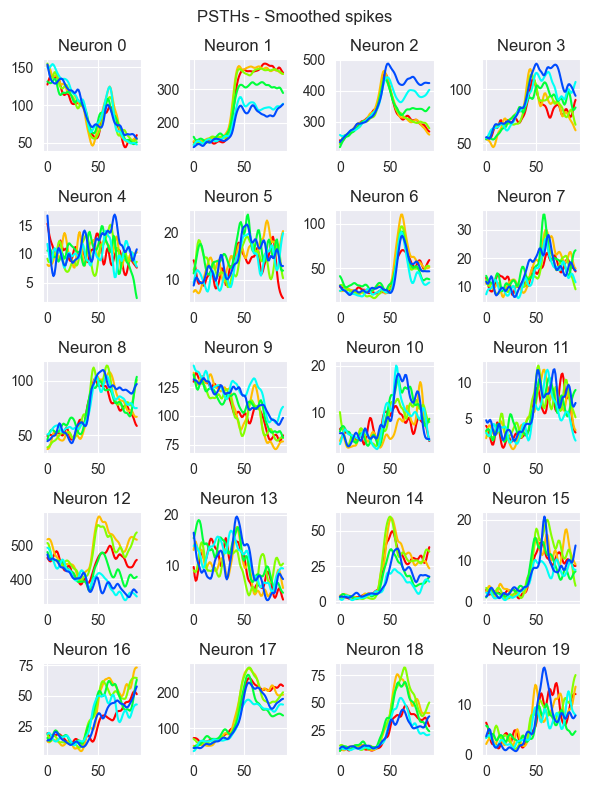

In [10]:
trial_conditions_train = int(trial_conditions_train[0] - 1)

plot_psths(smth_spikes_train, trial_conditions_train, "PSTHs - Smoothed spikes")

(346, 90)
(336, 90)
(332, 90)
(330, 90)
(334, 90)
(350, 90)


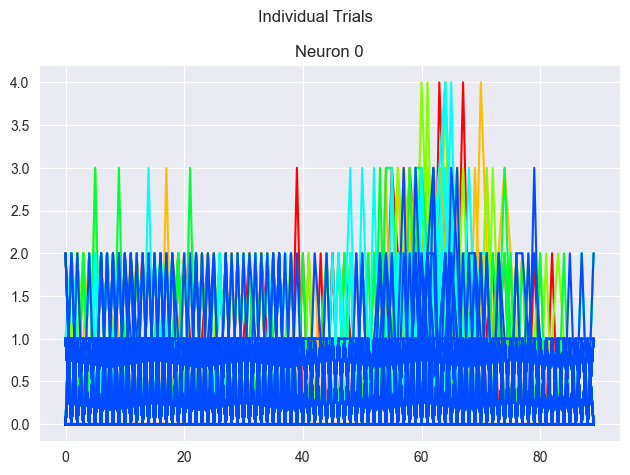

In [81]:
title = "Individual Trials"
plot_individ_trials_one_neuron(spike_tensor_binned_train, trial_conditions_train, title, neuron_id=0)

In [6]:
# load new transformer encoder
n_neurons = smth_spikes_train.shape[2]
n_time = smth_spikes_train.shape[1]
n_heads = 2
n_layers = 1
latent_dim = 100
version = 2
enc_model = EncTransformer(n_neurons, d_model=latent_dim, n_heads=n_heads, n_layers=n_layers)
enc_model.load_state_dict(torch.load(f'enctransformer_model_{n_layers}lay_{n_heads}heads_v{version}.pkl'))
enc_model.eval()
enc_preds = enc_model(torch.tensor(smth_spikes_train).to(torch.float32))

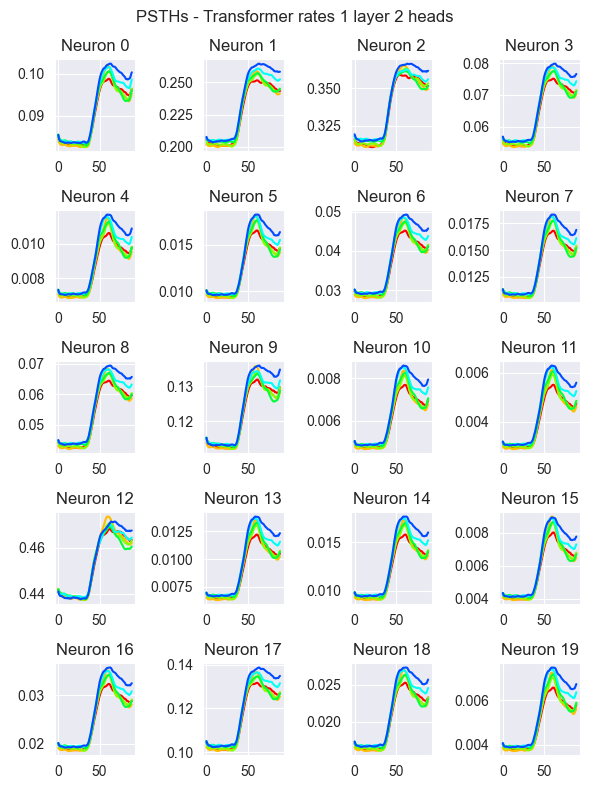

In [9]:
plot_psths(enc_preds.detach().numpy(), trial_conditions_train, f"PSTHs - Transformer rates {n_layers} layer {n_heads} heads")

In [10]:
# 2 layers, 2 heads
# load new transformer encoder
n_neurons = smth_spikes_train.shape[2]
n_time = smth_spikes_train.shape[1]
n_heads = 2
n_layers = 2
latent_dim = 100
version = 1
enc_model2 = EncTransformer(n_neurons, d_model=latent_dim, n_heads=n_heads, n_layers=n_layers)
enc_model2.load_state_dict(torch.load(f'enctransformer_model_{n_layers}lay_{n_heads}heads_v{version}.pkl'))
enc_model2.eval()
enc_preds2 = enc_model2(torch.tensor(smth_spikes_train).to(torch.float32))

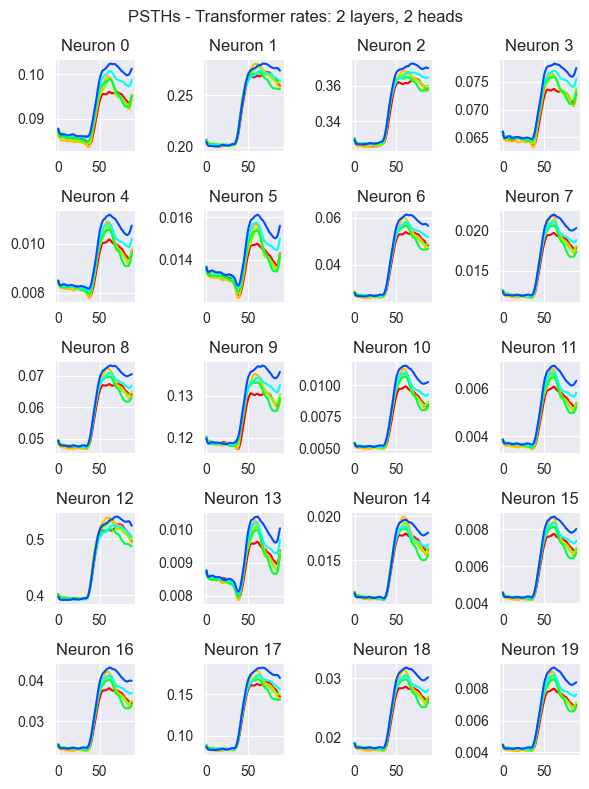

In [11]:
plot_psths(enc_preds2.detach().numpy(), trial_conditions_train, "PSTHs - Transformer rates: 2 layers, 2 heads")

In [12]:
# 2 layers, 6 heads
# load new transformer encoder
n_neurons = smth_spikes_train.shape[2]
n_time = smth_spikes_train.shape[1]
n_heads = 6
n_layers = 2
latent_dim = 100
version = 1
enc_model3 = EncTransformer(n_neurons, d_model=latent_dim, n_heads=n_heads, n_layers=n_layers)
enc_model3.load_state_dict(torch.load(f'enctransformer_model_{n_layers}lay_{n_heads}heads_v{version}.pkl'))
enc_model3.eval()
enc_preds3 = enc_model3(torch.tensor(smth_spikes_train).to(torch.float32))

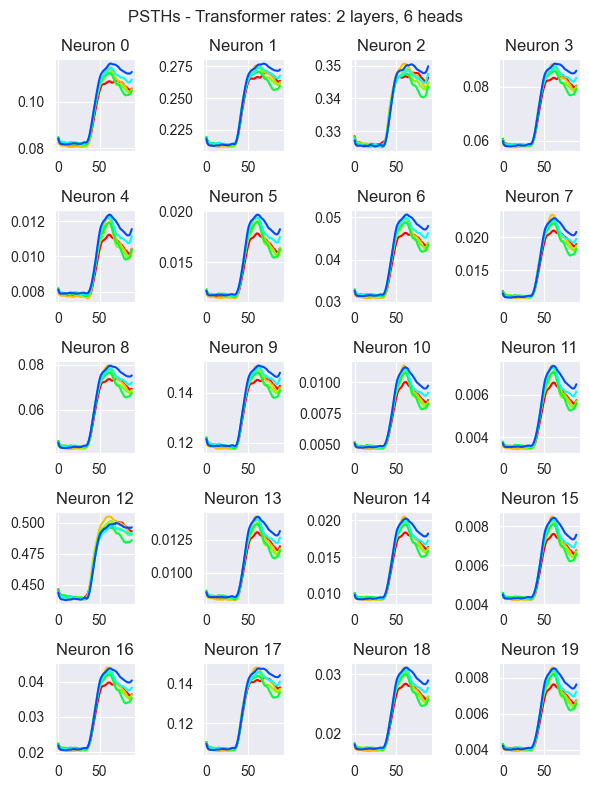

In [13]:
plot_psths(enc_preds3.detach().numpy(), trial_conditions_train, "PSTHs - Transformer rates: 2 layers, 6 heads")

In [14]:
# 2 layers, 6 heads l2 1e-5
n_neurons = smth_spikes_train.shape[2]
n_time = smth_spikes_train.shape[1]
n_heads = 6
n_layers = 2
latent_dim = 100
version = "l2_5"
enc_model4 = EncTransformer(n_neurons, d_model=latent_dim, n_heads=n_heads, n_layers=n_layers)
enc_model4.load_state_dict(torch.load(f'enctransformer_model_{n_layers}lay_{n_heads}heads_{version}.pkl'))
enc_model4.eval()
enc_preds4 = enc_model4(torch.tensor(smth_spikes_train).to(torch.float32))

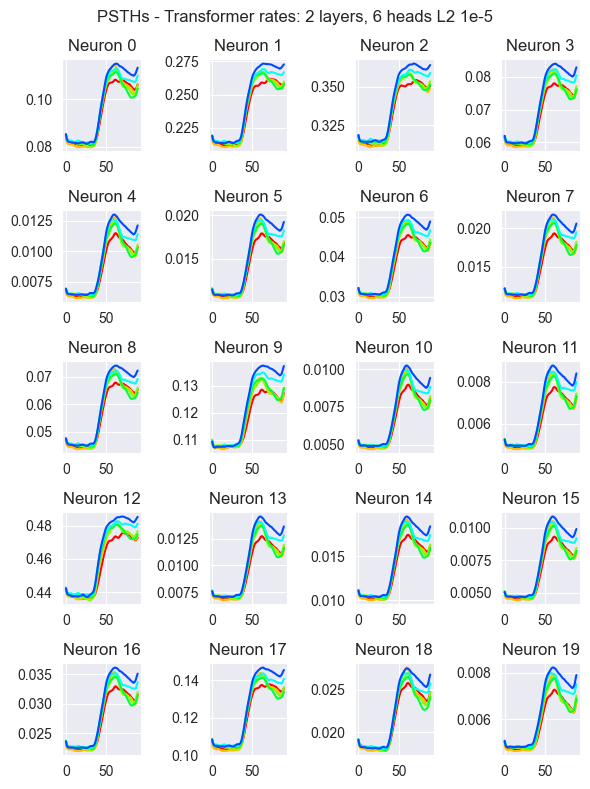

In [15]:
plot_psths(enc_preds4.detach().numpy(), trial_conditions_train, "PSTHs - Transformer rates: 2 layers, 6 heads L2 1e-5")

In [16]:
# 2 layers, 6 heads l2 1e-3
n_neurons = smth_spikes_train.shape[2]
n_time = smth_spikes_train.shape[1]
n_heads = 6
n_layers = 3
latent_dim = 100
version = "l2_3"
enc_model5 = EncTransformer(n_neurons, d_model=latent_dim, n_heads=n_heads, n_layers=n_layers)
enc_model5.load_state_dict(torch.load(f'enctransformer_model_{n_layers}lay_{n_heads}heads_{version}.pkl'))
enc_model5.eval()
enc_preds5 = enc_model5(torch.tensor(smth_spikes_train).to(torch.float32))

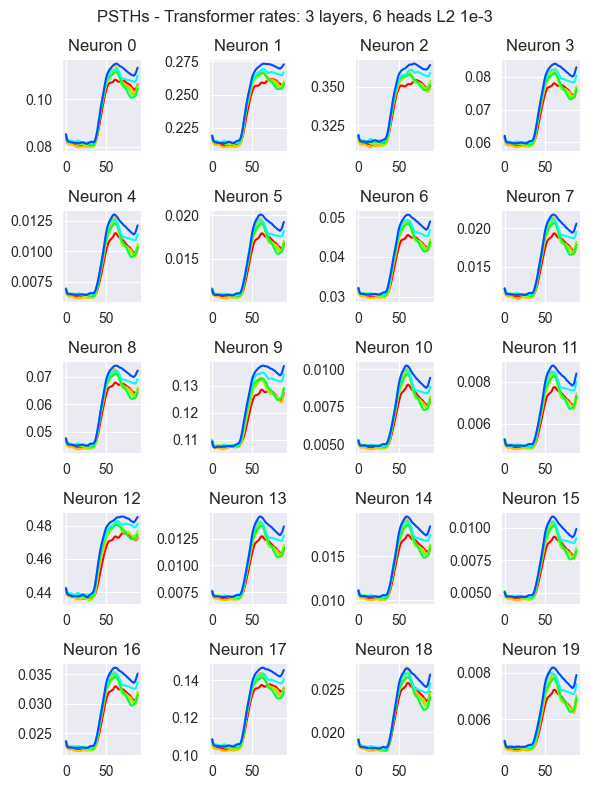

In [17]:
plot_psths(enc_preds4.detach().numpy(), trial_conditions_train, "PSTHs - Transformer rates: 3 layers, 6 heads L2 1e-3")

In [12]:
# 2 layers, 6 heads l2 1e-3
n_neurons = smth_spikes_train.shape[2]
n_time = smth_spikes_train.shape[1]
n_heads = 6
n_layers = 3
latent_dim = 100
version = "input_proj_layernorm"
enc_model6 = EncTransformer(n_neurons, d_model=latent_dim, n_heads=n_heads, n_layers=n_layers)
enc_model6.load_state_dict(torch.load(f'./train_output/enctransformer_model_{n_layers}lay_{n_heads}heads_{version}.pkl'))
enc_model6.eval()
enc_preds6 = enc_model6(torch.tensor(smth_spikes_train).to(torch.float32))

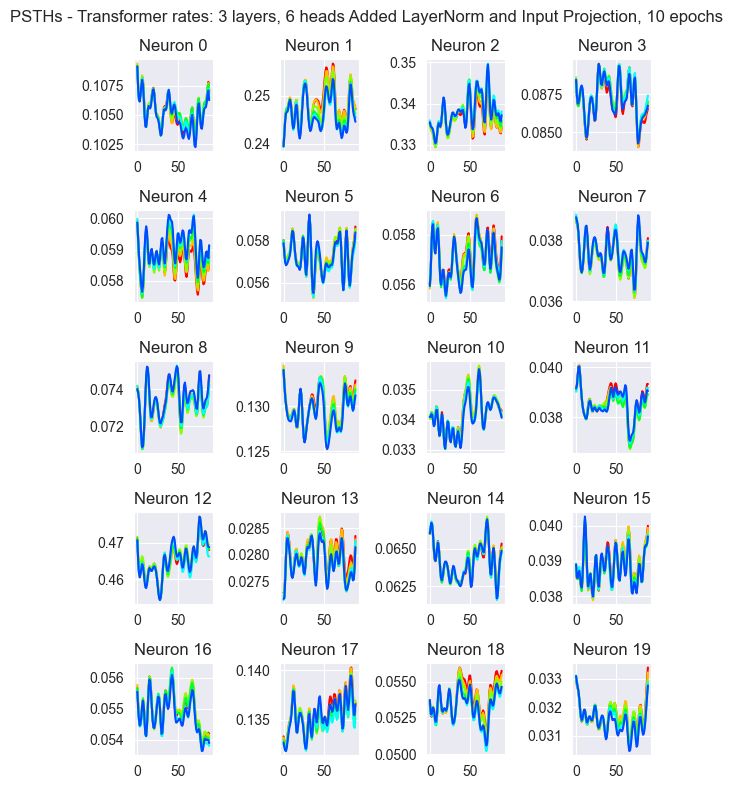

In [16]:
plot_psths(enc_preds6[0].detach().numpy(), trial_conditions_train, "PSTHs - Transformer rates: 3 layers, 6 heads Added LayerNorm and Input Projection, 10 epochs")

In [63]:
def plot_neural_traj(model_preds, trial_conditions, title):
    n_components = 10
    sess_psths = []
    for cond in np.unique(trial_conditions):
        mask = np.array(trial_conditions == cond)
        arr = model_preds[mask]
        psth = np.mean(arr, axis=0)
        sess_psths.append(psth)

    psths = np.array(sess_psths)
    psths_ccm = np.mean(psths, axis=0)

    psths_normalized = psths - psths_ccm
    psths_reshaped = psths_normalized.reshape(-1, psths.shape[-1])
    std_devs = np.std(psths_reshaped, axis=0)
    print(std_devs.shape)
    print("std zeros", sum(std_devs == 0))
    std_devs[std_devs == 0] = 1e-6
    print("std zeros after change", sum(std_devs == 0))
    combined_psths_ctrd = psths_reshaped/ std_devs
    #print("std dev ", np.std(psths_reshaped, axis=0))
    has_nan = np.isnan(combined_psths_ctrd).any()
    #has_inf = np.isinf(combined_psths_ctrd).any()
    print(has_nan)
    pca = PCA(n_components).fit(combined_psths_ctrd)


    combined_psth_pcs = pca.transform(combined_psths_ctrd)
    psth_pcs = combined_psth_pcs.reshape(psths.shape[0], psths.shape[1], n_components) # n_conditions, n_time, n_components (10)

    # --- Parameters ---
    n_conditions, n_timesteps, n_components = psth_pcs.shape  # psth_pcs = (conditions × time × PCs)
    colors = sns.color_palette("tab10", n_conditions)         # choose nice colors for conditions
    condition_labels = [f"Cond {i+1}" for i in range(n_conditions)]

    # --- Create 2D figure ---
    fig, ax = plt.subplots(figsize=(8, 6))

    # --- Plot trajectories ---
    for c in range(n_conditions):
        traj = psth_pcs[c]        # shape (time × n_components)
        ax.plot(
            traj[:, 0],            # PC1
            traj[:, 1],            # PC2
            color=colors[c],
            linewidth=2,
            label=condition_labels[c]
        )
        # mark start point
        ax.scatter(traj[0, 0], traj[0, 1], color=colors[c], s=50, marker='o')

    # --- Labels and title ---
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title('Neural Trajectories (PCA)' + title)
    ax.legend()
    ax.grid(True)

    plt.show()

(100,)
std zeros 33
std zeros after change 0
False


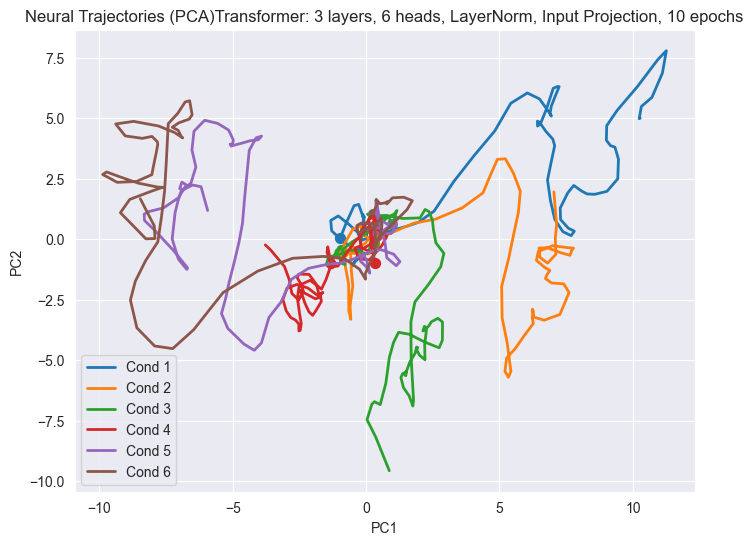

In [64]:
# plot neural trajectories
given_title = "Transformer: 3 layers, 6 heads, LayerNorm, Input Projection, 10 epochs"

plot_neural_traj(enc_preds6[1].detach().numpy(), trial_conditions_train, given_title)

In [41]:
# 2 layers, 6 heads l2 1e-3
n_neurons = smth_spikes_train.shape[2]
n_time = smth_spikes_train.shape[1]
n_heads = 6
n_layers = 3
latent_dim = 100
version = "input_proj_layernorm_20_eps"
enc_model7 = EncTransformer(n_neurons, d_model=latent_dim, n_heads=n_heads, n_layers=n_layers)
enc_model7.load_state_dict(torch.load(f'./train_output/enctransformer_model_{n_layers}lay_{n_heads}heads_{version}.pkl'))
enc_model7.eval()
enc_preds7 = enc_model7(torch.tensor(smth_spikes_train).to(torch.float32))

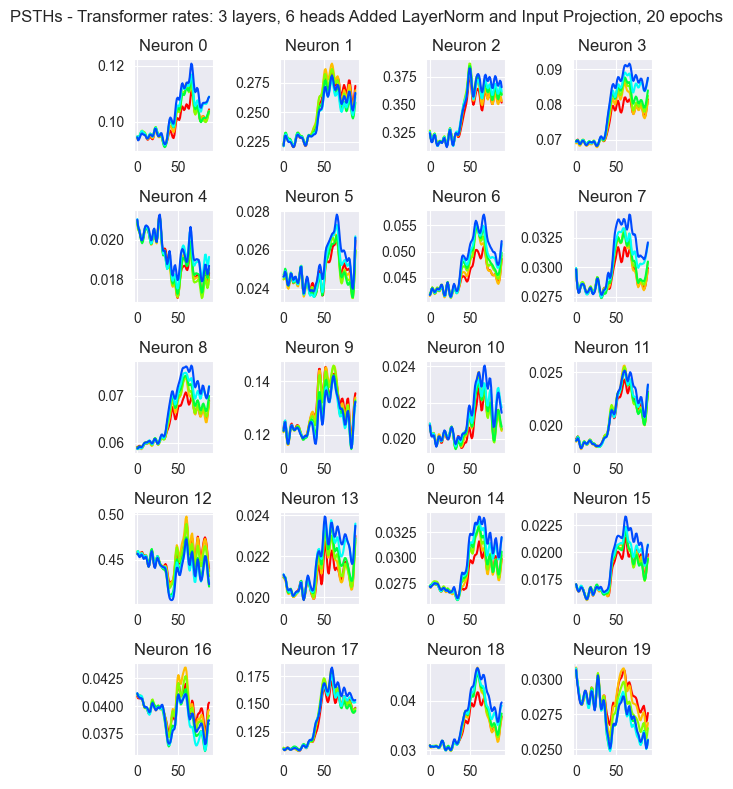

In [42]:
plot_psths(enc_preds7[0].detach().numpy(), trial_conditions_train, "PSTHs - Transformer rates: 3 layers, 6 heads Added LayerNorm and Input Projection, 20 epochs")

(100,)
std zeros 1
std zeros after change 0
False


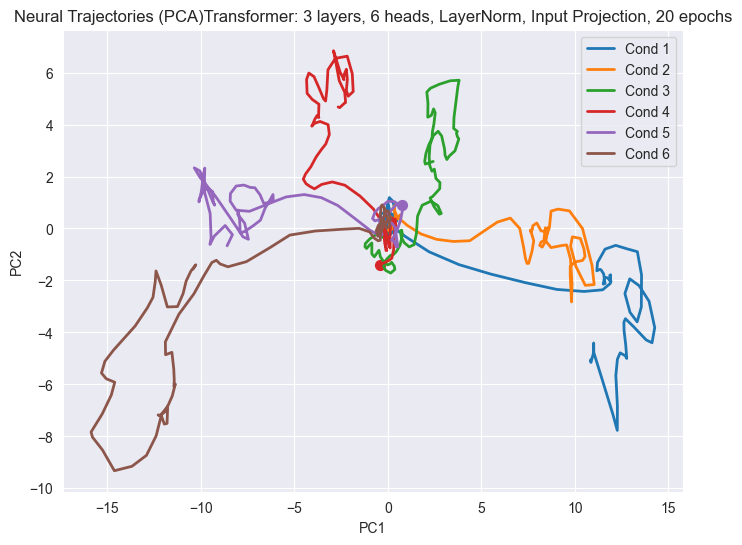

In [65]:
given_title = "Transformer: 3 layers, 6 heads, LayerNorm, Input Projection, 20 epochs"

plot_neural_traj(enc_preds7[1].detach().numpy(), trial_conditions_train, given_title)

In [54]:
arr = enc_preds7[1].detach().numpy()
print(type(enc_preds6[1].detach().numpy()))
nan_count = np.isnan(arr).sum()

print(nan_count)
has_nan = np.isnan(arr).any()
print(has_nan)
print(np.isinf(arr).any())

<class 'numpy.ndarray'>
0
False
False


(100,)
std zeros 0
std zeros after change 0
False


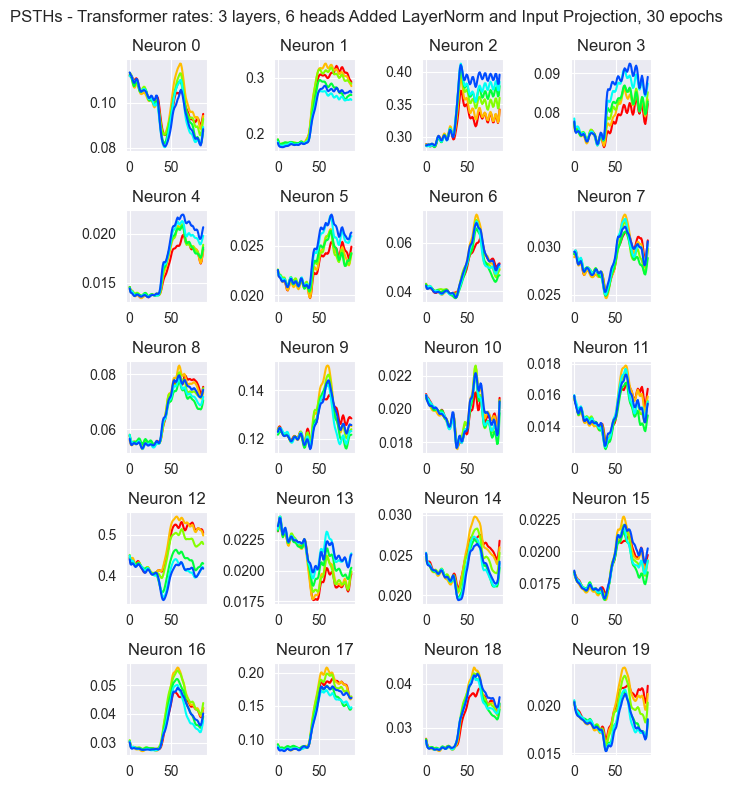

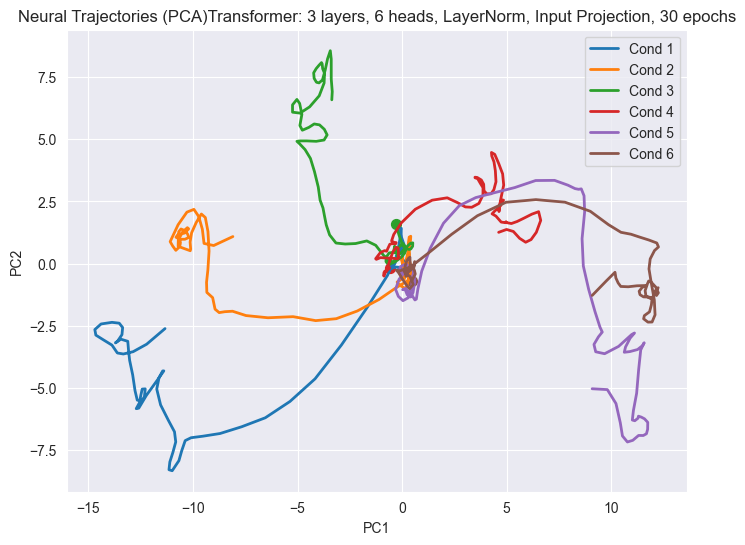

In [67]:
# 2 layers, 6 heads l2 1e-3
n_neurons = smth_spikes_train.shape[2]
n_time = smth_spikes_train.shape[1]
n_heads = 6
n_layers = 3
latent_dim = 100
version = "input_proj_layernorm_30_eps"
enc_model8 = EncTransformer(n_neurons, d_model=latent_dim, n_heads=n_heads, n_layers=n_layers)
enc_model8.load_state_dict(torch.load(f'./train_output/enctransformer_model_{n_layers}lay_{n_heads}heads_{version}.pkl'))
enc_model8.eval()
enc_preds8 = enc_model8(torch.tensor(smth_spikes_train).to(torch.float32))
plot_psths(enc_preds8[0].detach().numpy(), trial_conditions_train, "PSTHs - Transformer rates: 3 layers, 6 heads Added LayerNorm and Input Projection, 30 epochs")
given_title = "Transformer: 3 layers, 6 heads, LayerNorm, Input Projection, 30 epochs"

plot_neural_traj(enc_preds8[1].detach().numpy(), trial_conditions_train, given_title)

(100,)
std zeros 18
std zeros after change 0
False


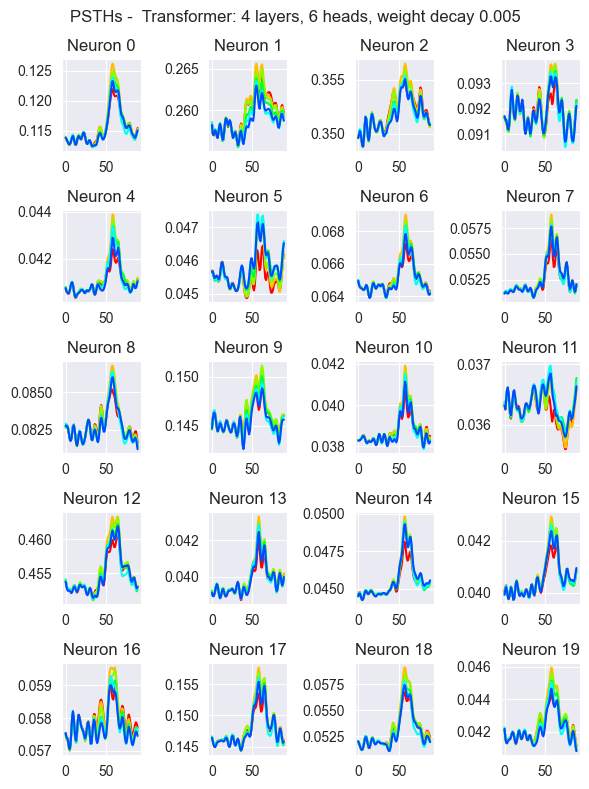

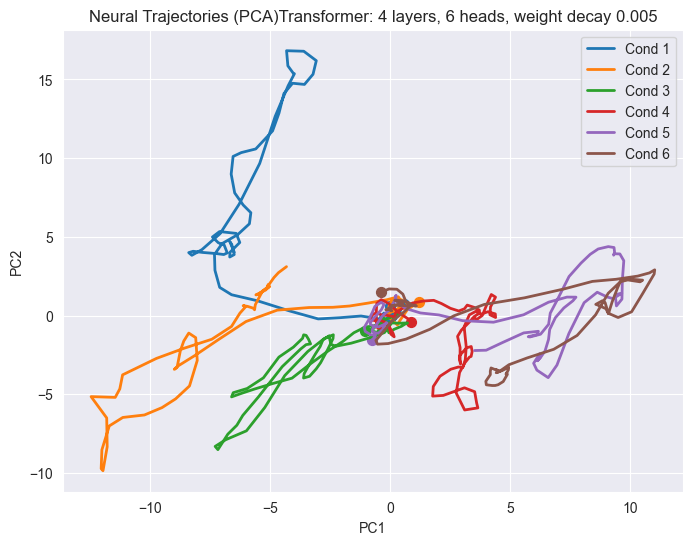

In [68]:
# 2 layers, 6 heads l2 1e-3
n_neurons = smth_spikes_train.shape[2]
n_time = smth_spikes_train.shape[1]
n_heads = 6
n_layers = 4
latent_dim = 100
version = "l2_005"
enc_model9 = EncTransformer(n_neurons, d_model=latent_dim, n_heads=n_heads, n_layers=n_layers)
enc_model9.load_state_dict(torch.load(f'./train_output/enctransformer_model_{n_layers}lay_{n_heads}heads_{version}.pkl'))
enc_model9.eval()
enc_preds9 = enc_model9(torch.tensor(smth_spikes_train).to(torch.float32))
title = "Transformer: 4 layers, 6 heads, weight decay 0.005"
plot_psths(enc_preds9[0].detach().numpy(), trial_conditions_train, "PSTHs -  " + title)

plot_neural_traj(enc_preds9[1].detach().numpy(), trial_conditions_train, title)

(100,)
std zeros 18
std zeros after change 0
False


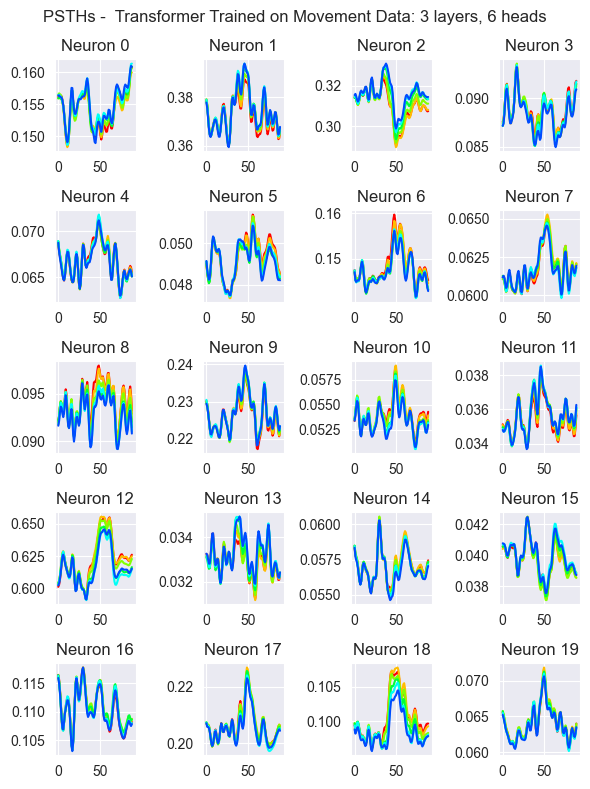

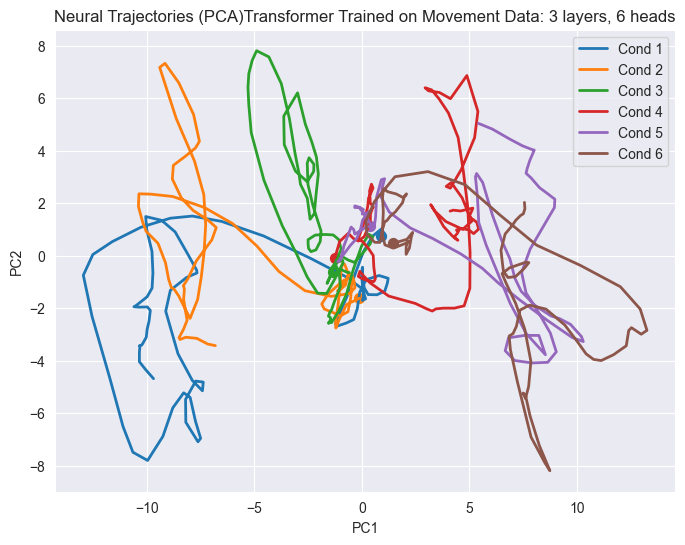

In [70]:
# 2 layers, 6 heads l2 1e-3
n_neurons = smth_spikes_train.shape[2]
n_time = smth_spikes_train.shape[1]
n_heads = 6
n_layers = 3
latent_dim = 100
version = "v1"
enc_model10 = EncTransformer(n_neurons, d_model=latent_dim, n_heads=n_heads, n_layers=n_layers)
enc_model10.load_state_dict(torch.load(f'./train_output_movement/enctransformer_model_{n_layers}lay_{n_heads}heads_{version}.pkl'))
enc_model10.eval()
enc_preds10 = enc_model10(torch.tensor(smth_spikes_train).to(torch.float32))
title = "Transformer Trained on Movement Data: 3 layers, 6 heads"
plot_psths(enc_preds10[0].detach().numpy(), trial_conditions_train, "PSTHs -  " + title)

plot_neural_traj(enc_preds10[1].detach().numpy(), trial_conditions_train, title)

Predicting Task Condition as a Function of Number of Time Steps

In [ ]:
# as a function of time, get the latent space from the model and predict condition
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score
def classify_cond(model, data, trial_conditions):
    n_trials = data.shape[0]
    n_time = data.shape[1]
    accuracies = []
    t = [i for i in range(5, n_time, 5)]
    for i in range(len(t)):
        curr_data = data[:, :t[i], :]
        #print(curr_data.shape)
        preds = model(torch.tensor(curr_data).to(torch.float32))
        latent = preds[1].clone().reshape(n_trials, -1).detach().numpy()
        ridge = RidgeClassifier(alpha=1.0)

        # Train the classifier
        eighty_percent = int(np.floor(n_trials * 0.8))
        ridge.fit(latent[:eighty_percent], trial_conditions[:eighty_percent])

        # Predict new values
        ridge_pred = ridge.predict(latent)
        accuracy = accuracy_score(trial_conditions_train, ridge_pred)
        accuracies.append(accuracy)
        print(t[i], accuracy)
    return accuracies

In [ ]:
accuracies = classify_cond(enc_model10, smth_spikes_train, trial_conditions_train)

In [ ]:
t = [i for i in range(5, n_time, 5)]
plt.plot(t, accuracies, marker='o')
#x = [i for i in range(5, n_time, 5)]
plt.xlabel("Time after trial onset")
plt.ylabel("Accuracy")
plt.title("Transformer on Movement Data")
plt.show()